<a href="https://colab.research.google.com/github/AbbasNkundizana/Rwizi_Climate/blob/master/precipitationDownscaling.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Connect to GEE**

In [113]:
!pip install --upgrade --pre xee
!pip install -U geemap

In [114]:
import ee

ee.Authenticate()
ee.Initialize(
    project = 'ee-abbas-nkundizana-isma',
    opt_url = 'https://earthengine-highvolume.googleapis.com'
)

# **Study Area **

In [115]:
import geemap

# Asset path (GEE)
roi_asset = (
    "projects/ee-abbas-nkundizana-isma/assets/Rwizi_catchment"
)

# Create map
Map = geemap.Map(
    basemap="SATELLITE"
)

# Load asset as an EE FeatureCollection
roi = ee.FeatureCollection(roi_asset)

# Visible boundary with transparency
roi_boundary = roi.style(
    color="blue",
    fillColor="00000000",
    width=3
)

# Add the roi to map
Map.addLayer(
    roi_boundary,
    {},
    "Rwizi catchment"
)

# Zoom to the Study Area
Map.centerObject(
    roi,
    10
)

#Map

# **Image Collections **

In [116]:
era5 = (
    ee.ImageCollection("ECMWF/ERA5_LAND/MONTHLY_AGGR")
    .filterDate('2015', '2026')
    .select(['total_precipitation_sum'],['pr'])
)

#era5

In [117]:
time_start = ee.Date('2015')
time_end = ee.Date('2026')

time_dif = time_end.difference(time_start, 'month').round()
time_list = ee.List.sequence(0, ee.Number(time_dif).subtract(1)).map(
    lambda x: time_start.advance(x, 'month')
)


In [118]:
time_list

def monthly(date_list, col):
  start_month = ee.Date(date_list)
  end_month = start_month.advance(1, 'month')
  col_month = col.filterDate(start_month, end_month).mean()
  return col_month.set('system:time_start', start_month.millis())


In [121]:
ndvi = (
    ee.ImageCollection("MODIS/061/MOD13A2")
    .filterDate(time_start, time_end)
    .select('NDVI','EVI')
)

#ndvi

In [122]:
lst = (
    ee.ImageCollection("MODIS/061/MOD11A2")
    .filterDate(time_start, time_end)
    .select('LST_Day_1km', 'LST_Night_1km')
)

#lst

In [123]:
et = (
    ee.ImageCollection("MODIS/061/MOD16A2GF")
    .filterDate(time_start, time_end)
    .select('ET','PET')
)

#et

In [124]:
topo = (
    ee.ImageCollection("JAXA/ALOS/AW3D30/V4_1")
    .mean().select('DSM')
)

#topo

In [125]:
lc = (
    ee.ImageCollection("MODIS/061/MCD12Q1")
    .filterDate(time_start, time_end)
    .select('LC_Type1')
    .mode()
)

#lc

# **Extract Monthly Collections**

In [126]:
ndvi_monthly = ee.ImageCollection(
    time_list.map(lambda x: monthly(x, ndvi))
)

lst_monthly = ee.ImageCollection(
    time_list.map(lambda x: monthly(x, lst))
)

et_monthly = ee.ImageCollection(
    time_list.map(lambda x: monthly(x, et))
)

#ndvi_monthly
#lst_monthly
#et_monthly

# **Monthly Collections Combo**

In [127]:
monthly_col = (
    ndvi_monthly
    .combine(lst_monthly)
    .combine(et_monthly)
    .map(lambda img: img.addBands(topo).addBands(lc))
)

#monthly_col


# **Convert to Xarray**

In [128]:
# Extract roi Geometry
roi_geometry = roi.geometry()

# Convert the Earth Engine geometry to a Shapely geometry.
roi_shapely = shape(
    roi_geometry.getInfo()
)

In [129]:

#Create a 10km Resolution Grid
grid_10km = helpers.fit_geometry(
    geometry=roi_shapely,
    geometry_crs="EPSG:4326",
    grid_crs="EPSG:4326",
    grid_scale=(0.1, -0.1)
)

#grid_10km

In [130]:
#Open EE monthly image collection as an Xarray Dataset on grid_10km
ds_10km = xr.open_dataset(
    monthly_col,
    engine = 'ee',
    **grid_10km
)

#Sort datasets chronologically multiplying numericals by 1
ds_10km = ds_10km.sortby('time') * 1




In [131]:
#Sort era5 Precipitation
pr_10km = xr.open_dataset(
    era5,
    engine = 'ee',
    **grid_10km
)

In [132]:
#Convert to mm
pr_10km = pr_10km.sortby('time') * 1000

In [133]:
#Combine collections with precipitation
ds_10km = xr.merge([ds_10km, pr_10km])

In [134]:
#Create spatial and temporal predictors (lat, long, month)
ds_10km['lon'] = ds_10km.x.broadcast_like(ds_10km.NDVI)
ds_10km['lat'] = ds_10km.y.broadcast_like(ds_10km.NDVI)
ds_10km['month'] = ds_10km.time.dt.month.broadcast_like(ds_10km.NDVI)


# **Sampling For Machine Learning**

In [135]:
#Convert ds_10km from Xarray Dataset into a Pandas DataFrame
df_10km = ds_10km.to_dataframe()

#df_10km


In [136]:
#Remove precipitation column from predictor table
x = df_10km.drop('pr', axis = 1)
x

NDVI     EVI  LST_Day_1km  LST_Night_1km      ET  \
time       y     x                                                           
2015-01-01 -0.25 30.25  7298.5  4200.0     14906.50   14542.750000  329.50   
                 30.35  6821.5  4210.5     14981.00   14399.750000  238.25   
                 30.45  6712.5  4350.5     15076.75   14396.250000  200.00   
                 30.55  6236.5  4151.5     15200.25   14445.000000  185.50   
                 30.65  6030.5  4003.0     15264.25   14413.500000  181.00   
...                        ...     ...          ...            ...     ...   
2025-12-01 -1.05 31.35  6482.0  4177.5     14963.00   14521.666992  161.25   
                 31.45  6849.0  4336.5     14937.00   14464.666992  172.25   
                 31.55  7438.5  3782.5     14960.00   14525.333008  181.00   
                 31.65  7264.0  3917.0     14951.00   14470.333008  165.00   
                 31.75  4161.0  1432.5     14700.00   14616.666992  145.50   

                           PET     DSM  LC_Type1    lon   lat  month  
time       y     x                                                    
2015-01-01 -0.25 30.25  517.25  1545.0       2.0  30.25 -0.25      1  
                 30.35  529.75  1416.0       9.0  30.35 -0.25      1  
                 30.45  530.00  1710.0      14.0  30.45 -0.25      1  
                 30.55  530.25  1485.0      14.0  30.55 -0.25      1  
                 30.65  528.50  1346.0       9.0  30.65 -0.25      1  
...                        ...     ...       ...    ...   ...    ...  
2025-12-01 -1.05 31.35  331.00  1187.0      10.0  31.35 -1.05     12  
                 31.45  329.50  1161.0      10.0  31.45 -1.05     12  
                 31.55  323.75  1159.0       9.0  31.55 -1.05     12  
                 31.65  321.25  1144.0       9.0  31.65 -1.05     12  
                 31.75  346.25  1161.0       9.0  31.75 -1.05     12  

[19008 rows x 11 columns]

In [138]:
#Define precipitation as target variable the model learns to predic
y = df_10km['pr']
#y

In [139]:
#Randomly allocate 80% of records to model training;
#20% to model testing.

from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size = 0.2, random_state = 42
)

# **Modelling**

In [140]:
from sklearn.ensemble import RandomForestRegressor

model = RandomForestRegressor(n_estimators = 100, random_state = 42)
model.fit(x_train, y_train)

RandomForestRegressor(random_state=42)

In [141]:
#Metrics
from sklearn.metrics import mean_squared_error, r2_score

y_pred = model.predict(x_test)

import numpy as np

rmse = np.sqrt(mean_squared_error(y_test, y_pred))

#rmse

r2 = r2_score(y_test, y_pred)

r2

0.8081857268127338

# **Prediction**

In [142]:
#Create a 1km Resolution Grid
grid_1km = helpers.fit_geometry(
    geometry = roi_shapely,
    grid_crs = 'EPSG:4326',
    grid_scale = (0.01, -0.01)
)

In [143]:
#Open EE monthly image collection as an Xarray Dataset on grid_1km
ds_1km = xr.open_dataset(
    monthly_col,
    engine = 'ee',
    **grid_1km
)

#ds_1km

In [144]:
##Sort datasets chronologically multiplying numericals by 1
ds_1km = ds_1km.sortby('time') * 1

In [145]:
#Create spatial and temporal predictors (lat, long, month)
ds_1km['lon'] = ds_1km.x.broadcast_like(ds_1km.NDVI)
ds_1km['lat'] = ds_1km.y.broadcast_like(ds_1km.NDVI)
ds_1km['month'] = ds_1km.time.dt.month.broadcast_like(ds_1km.NDVI)

In [146]:
#Convert ds_1km from Xarray Dataset into a Pandas DataFrame
df_1km = ds_1km.to_dataframe()

#df_1km

In [147]:
#Use trained model to predict precipitation_store as (pr_pred)
df_1km['pr_pred'] = model.predict(df_1km)

In [148]:
#Convert Pandas Column (pr_pred) back to Xarray
pr_1km = df_1km['pr_pred'].to_xarray()

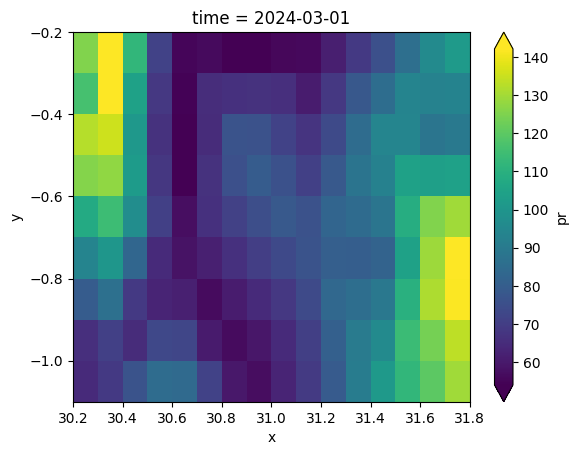

In [149]:
#Plot Spatial Distribution for One Time Step (Original Precipitation)
pr_10km.pr.isel(time = 110).plot(
    x = 'x', y = 'y', robust = True
)

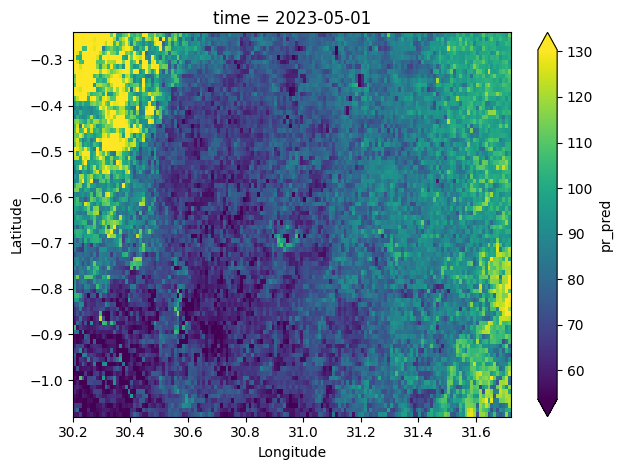

In [150]:
#Predicted Precipitation
pr_1km.isel(time = 100).plot(
    x = 'x', y = 'y', robust = True,
)

import matplotlib.pyplot as plt
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.tight_layout()
plt.show()

# **Point Extraction to csv**

In [159]:
#Extract and Export Monthly Predictions
import pandas as pd

#Rwizi Station Names and Cordinates
#1. Isingiro_814005; 30.816240, -0.815240
#2. Rakai_814017; 31.403100, -0.706100
#3. Rwonyo_814018; 30.96641, -0.63403

#Enter Station name and coordinates
station = 'Isingiro'
lon, lat = 30.816240, -0.815240

# Extract monthly precipitation values from nearest grid cell
point = pr_1km.sel(
    x=lon,
    y=lat,
    method='nearest'
).compute()

monthly_values = (
    point
    .to_series()
    .rename('Precipitation_mm')
    .reset_index()
    [['time', 'Precipitation_mm']]
    .rename(columns={'time': 'Date'})
)

# Export to CSV
output_csv = f'{station}.csv'

monthly_values.to_csv(
    output_csv,
    index=False
)

print('Station:', station)
print('Selected grid cell:', float(point.x), float(point.y))
print('csv saved as:', output_csv)

Station: Isingiro
Selected grid cell: 30.814999999999998 -0.8150000000000001
csv saved as: Isingiro.csv
